## Предобработка данных

In [1]:
#import sys
#!{sys.executable} -m pip install -U huggingface_hub fsspec accelerate


In [2]:
import json, os, random, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display

from sklearn.calibration import CalibratedClassifierCV
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, log_loss, roc_curve, auc as sk_auc,
)
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_sample_weight

from scipy.special import softmax

import torch
import evaluate
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    Trainer, TrainingArguments, logging as hf_logging,
)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [3]:
df = pd.read_csv("hf://datasets/MichiganNLP/MAiDE-up/all_data.csv")
df.head()


,Unnamed: 0,Review_Language,City Name,Hotel Name,Upside_Review,Downside_Review,Review_Score,Sentiment,source,Prompt_Language,na_up_review,na_down_review
0,0,Chinese,Ankara,迪万卡拉汉酒店,性价比超高的酒店，虽然价格比较贵，但是享受到的服务环境都还不错。,NaN,10.0,POS,0,NaN,False,True
1,1,Chinese,Ankara,迪万卡拉汉酒店,奥斯曼风格的建筑很有特色，房间装修精致，距离安卡拉城堡非常近，附近餐厅多，纪念品小商店多,不知道是不是因为夏季的原因，房间的空调不太给力，房间热；酒店员工会在窗外聊天，不考虑客人是不...,4.0,NEG,0,NaN,False,False
2,2,Chinese,Ankara,迪万卡拉汉酒店,非常喜歡酒店的環境氛圍，特別是通過地下通道到達博物館，這是一個驚喜（但入住時酒店服務人員并未...,酒店的空調令人傷心，第一天房間空調不起作用，次日上午出門時告知酒店經理，回來后依然沒有處理，...,5.0,NEG,0,NaN,False,False
3,3,Chinese,Ankara,安卡拉卡亚酒店,NaN,冷氣每隔5-15分鐘就會自動關閉，重新開啟有時候也要按三次才會開啟，飯店人員並沒有很積極地幫...,4.0,NEG,0,NaN,True,False
4,4,Chinese,Beijing,北京长城饭店(原北京喜来登长城饭店）,雖因為疫情影響加上老牌酒店旅客很少，但五星級的風骨猶存~這是寶藏好好傳承，比新酒店服務不到位強百倍,NaN,9.0,POS,0,NaN,False,True


In [4]:
df_ru = df[df["Review_Language"] == "Russian"].copy()
print("Размер до фильтрации:", len(df))
print("Размер после фильтрации:", len(df_ru))


Размер до фильтрации: 19985
Размер после фильтрации: 2000


In [5]:
# Векторизованное объединение Upside + Downside (без apply)
df_ru["text"] = (
    df_ru["Upside_Review"].fillna("") + " " + df_ru["Downside_Review"].fillna("")
).str.strip()

df_ru["label"] = df_ru["source"].astype(int)

display(df_ru["label"].value_counts().rename("count").to_frame())
df_ru[["text", "label"]].head()


,count
label,
0,1000
1,1000


,text,label
6985,Отдыхали в этом отеле с 9.05.2021 по 11.05.202...,0
6986,Расположение Не было уборки,0
6987,"Расположение, обслуживание, чистота Не нашел",0
6988,"Район хороший, есть много кафешек. На ресепшен...",0
6989,Все понравилось. Останавливался на одну ночь. ...,0


In [6]:
df_final = (
    df_ru[["text", "label"]]
    .copy()
    .loc[lambda d: d["text"].str.len() > 10]
    .reset_index(drop=True)   # важно для Dataset.from_pandas
)
print(f"Итоговый корпус: {len(df_final):,} отзывов")

Итоговый корпус: 2,000 отзывов


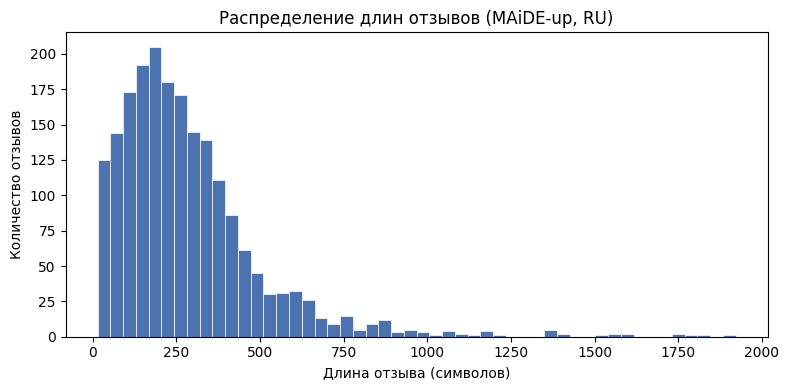

count    2000.0
mean      287.3
std       224.9
min        15.0
25%       141.8
50%       240.0
75%       366.0
max      1922.0


In [7]:
lengths = df_final["text"].str.len()

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50, color="#4C72B0", edgecolor="white", linewidth=0.5)
plt.xlabel("Длина отзыва (символов)")
plt.ylabel("Количество отзывов")
plt.title("Распределение длин отзывов (MAiDE-up, RU)")
plt.tight_layout()
plt.show()

print(lengths.describe().round(1).to_string())

## Разбиение данных на train / validation / test

In [8]:
VAL_SIZE  = 0.15
TEST_SIZE = 0.15

train_val_df, test_df = train_test_split(
    df_final,
    test_size=TEST_SIZE,
    random_state=seed,
    stratify=df_final["label"]
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=VAL_SIZE / (1 - TEST_SIZE),  # ≈ 0.1765 → ровно 15% от общего
    random_state=seed,
    stratify=train_val_df["label"]
)

print(f"{'Split':12s}  {'N':>5s}  {'real':>5s}  {'fake':>5s}  {'%fake':>6s}")
print("-" * 40)
for name, split in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    n, f = len(split), split["label"].sum()
    print(f"{name:12s}  {n:5d}  {n-f:5d}  {f:5d}  {f/n*100:5.1f}%")

Split             N   real   fake   %fake
----------------------------------------
Train          1400    700    700   50.0%
Validation      300    150    150   50.0%
Test            300    150    150   50.0%


Поскольку исходный корпус содержит сбалансированное распределение классов (50/50),
при разбиении применялась стратификация по целевой переменной.
Пропорция разбиения: 70% / 15% / 15%.

## Baseline: TF-IDF + Logistic Regression

In [9]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.9)
X_train_tfidf = tfidf.fit_transform(train_df["text"])
X_val_tfidf   = tfidf.transform(val_df["text"])
X_test_tfidf  = tfidf.transform(test_df["text"])
print(f"TF-IDF матрица (train): {X_train_tfidf.shape}")


TF-IDF матрица (train): (1400, 4738)


In [10]:
# Датасет сбалансирован (50/50) — class_weight не нужен
logreg = LogisticRegression(max_iter=2000, random_state=seed)
logreg.fit(X_train_tfidf, train_df["label"])

val_preds_lr = logreg.predict(X_val_tfidf)
print("Validation — TF-IDF + LogReg")
print(classification_report(val_df["label"], val_preds_lr, digits=4))


Validation — TF-IDF + LogReg
              precision    recall  f1-score   support

           0     0.9477    0.9667    0.9571       150
           1     0.9660    0.9467    0.9562       150

    accuracy                         0.9567       300
   macro avg     0.9568    0.9567    0.9567       300
weighted avg     0.9568    0.9567    0.9567       300



## TF-IDF + SVM

In [11]:
# Датасет сбалансирован — class_weight не нужен
svm = CalibratedClassifierCV(
    LinearSVC(random_state=seed, max_iter=5000),
    method="sigmoid", cv=3
)
svm.fit(X_train_tfidf, train_df["label"])

val_preds_svm = svm.predict(X_val_tfidf)
print("Validation — TF-IDF + SVM")
print(classification_report(val_df["label"], val_preds_svm, digits=4))

Validation — TF-IDF + SVM
              precision    recall  f1-score   support

           0     0.9539    0.9667    0.9603       150
           1     0.9662    0.9533    0.9597       150

    accuracy                         0.9600       300
   macro avg     0.9601    0.9600    0.9600       300
weighted avg     0.9601    0.9600    0.9600       300



## RuBERT (cointegrated/rubert-tiny2)

In [12]:
MODEL_NAME = "cointegrated/rubert-tiny2"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_tok_dataset(df_split):
    ds = Dataset.from_pandas(df_split[["text", "label"]].reset_index(drop=True))
    ds = ds.map(
        lambda b: tokenizer(b["text"], truncation=True,
                            padding="max_length", max_length=256),
        batched=True,
    )
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    return ds

train_tok = make_tok_dataset(train_df)
val_tok   = make_tok_dataset(val_df)
test_tok  = make_tok_dataset(test_df)

Map:   0%|          | 0/1400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [13]:
_metric_f1  = evaluate.load("f1")
_metric_acc = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": _metric_acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1":       _metric_f1.compute(predictions=preds, references=labels, average="binary")["f1"],
    }

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

training_args = TrainingArguments(
    output_dir                  = "rubert_fake_reviews",
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    learning_rate               = 2e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    num_train_epochs            = 4,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    logging_steps               = 50,
    report_to                   = "none",
    seed                        = seed,
    data_seed                   = seed,
    dataloader_pin_memory       = False,
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_tok,
    eval_dataset    = val_tok,
    compute_metrics = compute_metrics,
)
trainer.train()

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

{'loss': '0.6725', 'grad_norm': '1.521', 'learning_rate': '1.918e-05', 'epoch': '0.5682'}
{'eval_loss': '0.5035', 'eval_accuracy': '0.89', 'eval_f1': '0.8946', 'eval_runtime': '0.792', 'eval_samples_per_second': '378.8', 'eval_steps_per_second': '23.99', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.5483', 'grad_norm': '1.64', 'learning_rate': '1.601e-05', 'epoch': '1.136'}
{'loss': '0.373', 'grad_norm': '3.652', 'learning_rate': '1.285e-05', 'epoch': '1.705'}
{'eval_loss': '0.2765', 'eval_accuracy': '0.9133', 'eval_f1': '0.9128', 'eval_runtime': '0.78', 'eval_samples_per_second': '384.6', 'eval_steps_per_second': '24.36', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.152', 'grad_norm': '2.311', 'learning_rate': '3.354e-06', 'epoch': '3.409'}
{'loss': '0.159', 'grad_norm': '3.855', 'learning_rate': '1.899e-07', 'epoch': '3.977'}
{'eval_loss': '0.2146', 'eval_accuracy': '0.9167', 'eval_f1': '0.9169', 'eval_runtime': '0.8918', 'eval_samples_per_second': '336.4', 'eval_steps_per_second': '21.3', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '63.69', 'train_samples_per_second': '87.92', 'train_steps_per_second': '5.527', 'train_loss': '0.337', 'epoch': '4'}


TrainOutput(global_step=352, training_loss=0.3369725377044894, metrics={'train_runtime': 63.693, 'train_samples_per_second': 87.922, 'train_steps_per_second': 5.527, 'train_loss': 0.3369725377044894, 'epoch': 4.0})

## Оценка моделей на тестовой выборке

In [14]:
# Предсказания всех моделей на тесте
test_preds_lr  = logreg.predict(X_test_tfidf)
test_probs_lr  = logreg.predict_proba(X_test_tfidf)[:, 1]

test_preds_svm = svm.predict(X_test_tfidf)
test_probs_svm = svm.predict_proba(X_test_tfidf)[:, 1]

pred_test       = trainer.predict(test_tok)
test_preds_bert = np.argmax(pred_test.predictions, axis=1)
test_probs_bert = softmax(pred_test.predictions, axis=1)[:, 1]  # softmax из логитов!

for name, preds in [
    ("TF-IDF + LogReg", test_preds_lr),
    ("TF-IDF + SVM",    test_preds_svm),
    ("RuBERT",          test_preds_bert),
]:
    print(f"── {name} ──")
    print(classification_report(test_df["label"], preds, digits=4))

── TF-IDF + LogReg ──
              precision    recall  f1-score   support

           0     0.9119    0.9667    0.9385       150
           1     0.9645    0.9067    0.9347       150

    accuracy                         0.9367       300
   macro avg     0.9382    0.9367    0.9366       300
weighted avg     0.9382    0.9367    0.9366       300

── TF-IDF + SVM ──
              precision    recall  f1-score   support

           0     0.9172    0.9600    0.9381       150
           1     0.9580    0.9133    0.9352       150

    accuracy                         0.9367       300
   macro avg     0.9376    0.9367    0.9366       300
weighted avg     0.9376    0.9367    0.9366       300

── RuBERT ──
              precision    recall  f1-score   support

           0     0.9404    0.9467    0.9435       150
           1     0.9463    0.9400    0.9431       150

    accuracy                         0.9433       300
   macro avg     0.9434    0.9433    0.9433       300
weighted avg     0.9

## Ансамблирование (soft voting)

In [15]:
# Val-вероятности вычисляем ОДИН раз для обоих ансамблей
val_probs_lr   = logreg.predict_proba(X_val_tfidf)[:, 1]
val_probs_svm  = svm.predict_proba(X_val_tfidf)[:, 1]

pred_val_bert  = trainer.predict(val_tok)
val_probs_bert = softmax(pred_val_bert.predictions, axis=1)[:, 1]
y_val          = val_df["label"].to_numpy()

def tune_ensemble(probs_a, probs_b, y_true, n_w=21, n_t=81):
    """Подбирает w и t, максимизируя F1 на val. Test не трогаем."""
    best_f1, best_w, best_t = -1, 0.5, 0.5
    for w in np.linspace(0, 1, n_w):
        ens = w * probs_a + (1 - w) * probs_b
        for t in np.linspace(0.1, 0.9, n_t):
            f1 = f1_score(y_true, (ens >= t).astype(int))
            if f1 > best_f1:
                best_f1, best_w, best_t = f1, w, t
    return best_w, best_t, best_f1

In [16]:
# Ensemble 1: TF-IDF + RuBERT
best_w_lr, best_t_lr, val_f1_lr = tune_ensemble(val_probs_lr, val_probs_bert, y_val)
print(f"TF-IDF+RuBERT  val → w={best_w_lr:.2f}, t={best_t_lr:.2f}, F1={val_f1_lr:.4f}")

ens_probs_lr_bert = best_w_lr * test_probs_lr + (1 - best_w_lr) * test_probs_bert
ens_preds_lr_bert = (ens_probs_lr_bert >= best_t_lr).astype(int)

print(classification_report(test_df["label"], ens_preds_lr_bert, digits=4))

TF-IDF+RuBERT  val → w=0.80, t=0.47, F1=0.9701
              precision    recall  f1-score   support

           0     0.9295    0.9667    0.9477       150
           1     0.9653    0.9267    0.9456       150

    accuracy                         0.9467       300
   macro avg     0.9474    0.9467    0.9466       300
weighted avg     0.9474    0.9467    0.9466       300



In [17]:
# Ensemble 2: SVM + RuBERT
best_w_svm, best_t_svm, val_f1_svm = tune_ensemble(val_probs_svm, val_probs_bert, y_val)
print(f"SVM+RuBERT     val → w={best_w_svm:.2f}, t={best_t_svm:.2f}, F1={val_f1_svm:.4f}")

ens_probs_svm_bert = best_w_svm * test_probs_svm + (1 - best_w_svm) * test_probs_bert
ens_preds_svm_bert = (ens_probs_svm_bert >= best_t_svm).astype(int)

print(classification_report(test_df["label"], ens_preds_svm_bert, digits=4))

SVM+RuBERT     val → w=0.65, t=0.43, F1=0.9637
              precision    recall  f1-score   support

           0     0.9359    0.9733    0.9542       150
           1     0.9722    0.9333    0.9524       150

    accuracy                         0.9533       300
   macro avg     0.9541    0.9533    0.9533       300
weighted avg     0.9541    0.9533    0.9533       300



## Анализ ошибок

In [18]:
test_df = test_df.copy()
test_df["pred_lr"]            = test_preds_lr
test_df["pred_svm"]           = test_preds_svm
test_df["pred_bert"]          = test_preds_bert
test_df["pred_ens_lr_bert"]   = ens_preds_lr_bert
test_df["pred_ens_svm_bert"]  = ens_preds_svm_bert

print(f"{'Модель':38s}  {'Ошибок':>7s}  {'Accuracy':>9s}  {'F1':>7s}")
print("-" * 68)
for col, name in [
    ("pred_lr",           "TF-IDF + LogReg"),
    ("pred_svm",          "TF-IDF + SVM"),
    ("pred_bert",         "RuBERT"),
    ("pred_ens_lr_bert",  f"Ensemble LR+BERT  (w={best_w_lr:.2f})"),
    ("pred_ens_svm_bert", f"Ensemble SVM+BERT (w={best_w_svm:.2f})"),
]:
    n_err = (test_df["label"] != test_df[col]).sum()
    print(f"{name:38s}  {n_err:7d}  "
          f"{accuracy_score(test_df['label'], test_df[col]):9.4f}  "
          f"{f1_score(test_df['label'], test_df[col]):7.4f}")

Модель                                   Ошибок   Accuracy       F1
--------------------------------------------------------------------
TF-IDF + LogReg                              19     0.9367   0.9347
TF-IDF + SVM                                 19     0.9367   0.9352
RuBERT                                       17     0.9433   0.9431
Ensemble LR+BERT  (w=0.80)                   16     0.9467   0.9456
Ensemble SVM+BERT (w=0.65)                   14     0.9533   0.9524


In [19]:
# Примеры ошибочных предсказаний RuBERT
errors_bert = test_df[test_df["label"] != test_df["pred_bert"]][["text","label","pred_bert"]]
print(f"Ошибок RuBERT: {len(errors_bert)}")
errors_bert.head(5)

Ошибок RuBERT: 17


,text,label,pred_bert
1195,Находится недалеко от станции Номера маленькие...,1,0
1227,"Отличное расположение, очень близко до станции...",1,0
772,"Номер очень чистый и удобный, расположение отл...",0,1
1605,В хорошем местоположении малостный и плохо обс...,1,0
1776,"Отличное местоположение, стильные и чистые ком...",1,0


## Итоговые метрики

In [20]:
results = pd.DataFrame([
    {"Model": name,
     "Test accuracy": accuracy_score(test_df["label"], preds),
     "Test F1":       f1_score(test_df["label"], preds)}
    for name, preds in [
        ("TF-IDF + LogReg",                               test_preds_lr),
        ("TF-IDF + SVM",                                  test_preds_svm),
        ("RuBERT",                                        test_preds_bert),
        (f"Ensemble LR+BERT  (w={best_w_lr:.2f},t={best_t_lr:.2f})",   ens_preds_lr_bert),
        (f"Ensemble SVM+BERT (w={best_w_svm:.2f},t={best_t_svm:.2f})", ens_preds_svm_bert),
    ]
]).sort_values("Test F1", ascending=False).reset_index(drop=True)

results.style.format({"Test accuracy": "{:.4f}", "Test F1": "{:.4f}"}) \
             .background_gradient(subset=["Test F1","Test accuracy"], cmap="Greens")

,Model,Test accuracy,Test F1
0,"Ensemble SVM+BERT (w=0.65,t=0.43)",0.9533,0.9524
1,"Ensemble LR+BERT (w=0.80,t=0.47)",0.9467,0.9456
2,RuBERT,0.9433,0.9431
3,TF-IDF + SVM,0.9367,0.9352
4,TF-IDF + LogReg,0.9367,0.9347


## Визуализация результатов

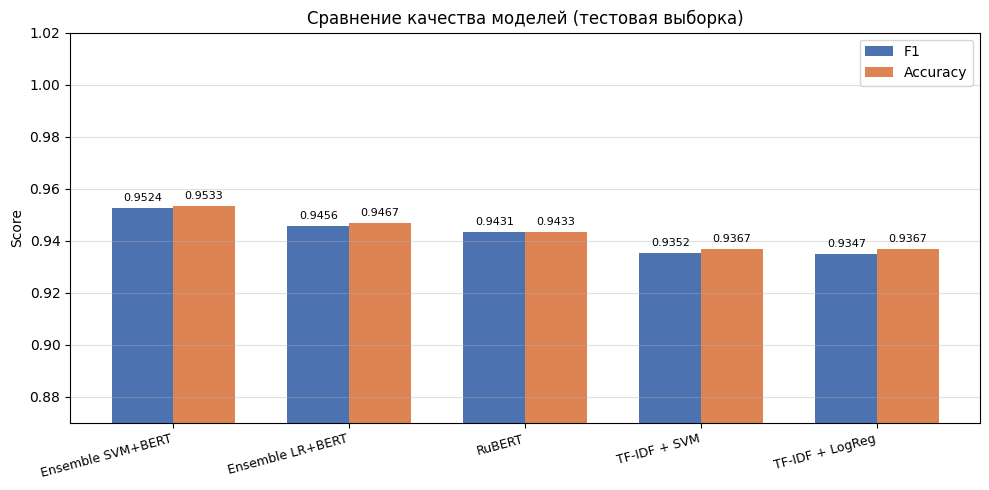

In [21]:
# Grouped bar: F1 и Accuracy для всех моделей
labels = results["Model"].str.replace(r"\s+\(.*\)", "", regex=True)
x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, results["Test F1"],       w, label="F1",       color="#4C72B0")
ax.bar(x + w/2, results["Test accuracy"], w, label="Accuracy", color="#DD8452")

for i, (f1, acc) in enumerate(zip(results["Test F1"], results["Test accuracy"])):
    ax.text(i - w/2, f1  + 0.002, f"{f1:.4f}",  ha="center", va="bottom", fontsize=8)
    ax.text(i + w/2, acc + 0.002, f"{acc:.4f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
ax.set_ylim(0.87, 1.02)
ax.set_ylabel("Score")
ax.set_title("Сравнение качества моделей (тестовая выборка)")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

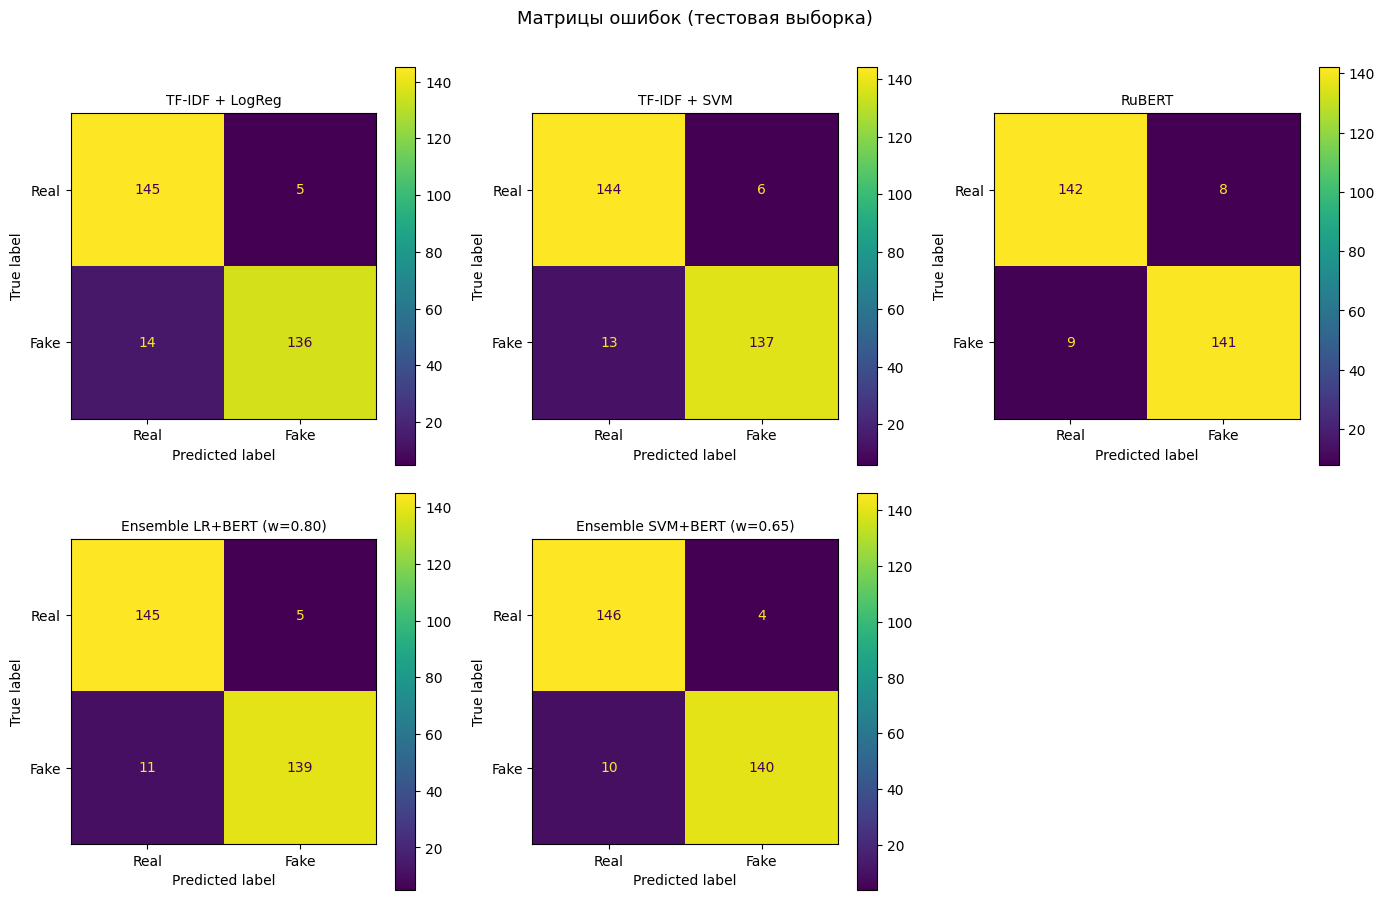

In [22]:
# Матрицы ошибок — все 5 моделей на одном рисунке
cm_data = [
    ("TF-IDF + LogReg",                    test_preds_lr),
    ("TF-IDF + SVM",                       test_preds_svm),
    ("RuBERT",                             test_preds_bert),
    (f"Ensemble LR+BERT (w={best_w_lr:.2f})",  ens_preds_lr_bert),
    (f"Ensemble SVM+BERT (w={best_w_svm:.2f})", ens_preds_svm_bert),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, (name, preds) in enumerate(cm_data):
    cm = confusion_matrix(test_df["label"], preds)
    ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"]).plot(ax=axes[i])
    axes[i].set_title(name, fontsize=10)

axes[-1].set_visible(False)   # последняя ячейка пустая
plt.suptitle("Матрицы ошибок (тестовая выборка)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

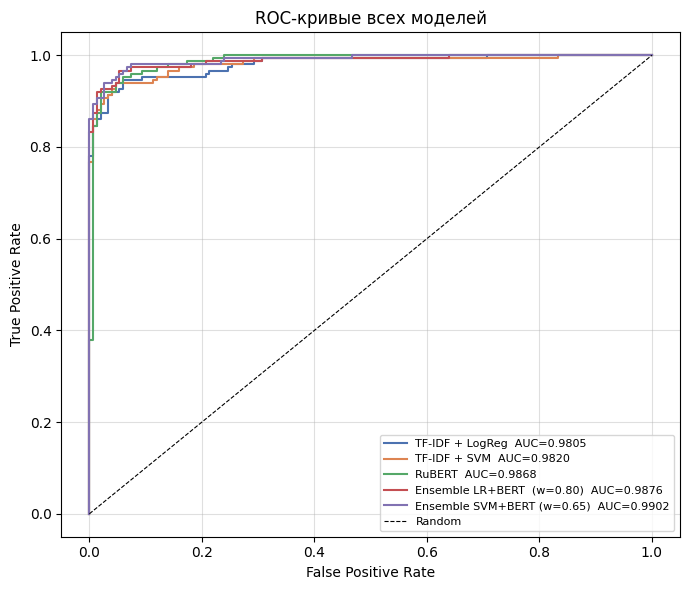

In [23]:
# ROC-кривые всех моделей на одном графике
roc_models = [
    ("TF-IDF + LogReg",                    test_probs_lr,       "#4C72B0"),
    ("TF-IDF + SVM",                       test_probs_svm,      "#DD8452"),
    ("RuBERT",                             test_probs_bert,     "#55A868"),
    (f"Ensemble LR+BERT  (w={best_w_lr:.2f})",  ens_probs_lr_bert,  "#C44E52"),
    (f"Ensemble SVM+BERT (w={best_w_svm:.2f})", ens_probs_svm_bert, "#8172B2"),
]

plt.figure(figsize=(7, 6))
for name, probs, color in roc_models:
    fpr, tpr, _ = roc_curve(test_df["label"], probs)
    plt.plot(fpr, tpr, label=f"{name}  AUC={sk_auc(fpr,tpr):.4f}", color=color)

plt.plot([0,1],[0,1], "k--", linewidth=0.8, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые всех моделей")
plt.legend(fontsize=8, loc="lower right")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

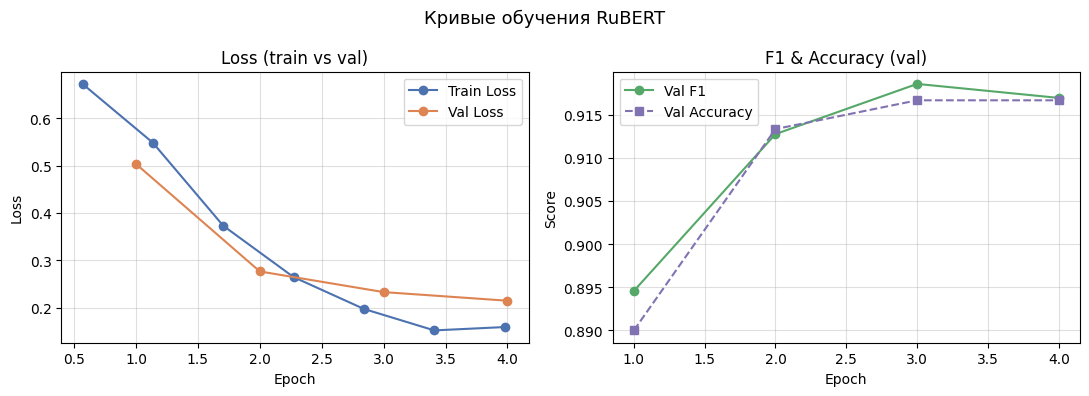

In [24]:
# Кривые обучения RuBERT из логов Trainer
log_hist   = pd.DataFrame(trainer.state.log_history)
train_logs = (log_hist.dropna(subset=["loss"])
              .groupby("epoch")[["loss"]].mean())
eval_logs  = (log_hist.dropna(subset=["eval_loss"])
              .groupby("epoch")[["eval_loss","eval_f1","eval_accuracy"]].mean())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(train_logs.index, train_logs["loss"], marker="o", label="Train Loss", color="#4C72B0")
ax1.plot(eval_logs.index,  eval_logs["eval_loss"], marker="o", label="Val Loss",   color="#DD8452")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss (train vs val)"); ax1.legend(); ax1.grid(alpha=0.4)

ax2.plot(eval_logs.index, eval_logs["eval_f1"],       marker="o", label="Val F1",       color="#55A868")
ax2.plot(eval_logs.index, eval_logs["eval_accuracy"], marker="s", label="Val Accuracy", color="#8172B2", linestyle="--")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score")
ax2.set_title("F1 & Accuracy (val)"); ax2.legend(); ax2.grid(alpha=0.4)

plt.suptitle("Кривые обучения RuBERT", fontsize=13)
plt.tight_layout()
plt.show()

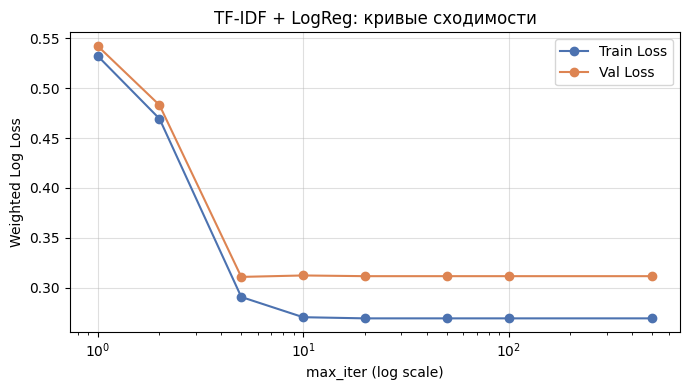

In [25]:
# Кривые сходимости логистической регрессии
iters = [1, 2, 5, 10, 20, 50, 100, 500]
train_losses, val_losses = [], []

sw_tr = compute_sample_weight("balanced", y=train_df["label"].to_numpy())
sw_va = compute_sample_weight("balanced", y=val_df["label"].to_numpy())

for m in iters:
    lr_tmp = LogisticRegression(max_iter=m, random_state=seed)
    lr_tmp.fit(X_train_tfidf, train_df["label"])
    train_losses.append(log_loss(train_df["label"], lr_tmp.predict_proba(X_train_tfidf), sample_weight=sw_tr))
    val_losses.append(  log_loss(val_df["label"],   lr_tmp.predict_proba(X_val_tfidf),   sample_weight=sw_va))

plt.figure(figsize=(7, 4))
plt.plot(iters, train_losses, marker="o", label="Train Loss", color="#4C72B0")
plt.plot(iters, val_losses,   marker="o", label="Val Loss",   color="#DD8452")
plt.xscale("log")
plt.xlabel("max_iter (log scale)")
plt.ylabel("Weighted Log Loss")
plt.title("TF-IDF + LogReg: кривые сходимости")
plt.legend(); plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## Экспорт моделей

In [26]:
import joblib, os

# Сохраняем всё в папку курсовой
os.chdir("/Users/yana/Курсовая 3 курс")
os.makedirs("models/rubert", exist_ok=True)

joblib.dump(tfidf,  "models/tfidf_vectorizer.pkl")
joblib.dump(logreg, "models/logreg_model.pkl")
joblib.dump(svm,    "models/svm_model.pkl")

ensemble_params = {
    "tfidf_rubert": {"w": float(best_w_lr),  "t": float(best_t_lr)},
    "svm_rubert":   {"w": float(best_w_svm), "t": float(best_t_svm)},
}
with open("models/ensemble_params.json", "w") as f:
    json.dump(ensemble_params, f, indent=2)

model.save_pretrained("models/rubert/")
tokenizer.save_pretrained("models/rubert/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('models/rubert/tokenizer_config.json', 'models/rubert/tokenizer.json')